<a href="https://colab.research.google.com/github/mankudeepika123-rgb/Heritage-Treasures-An-In-Depth-Analysis-of-UNESCO-World-Heritage-Sites-2019-/blob/main/codec_tech.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn

Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


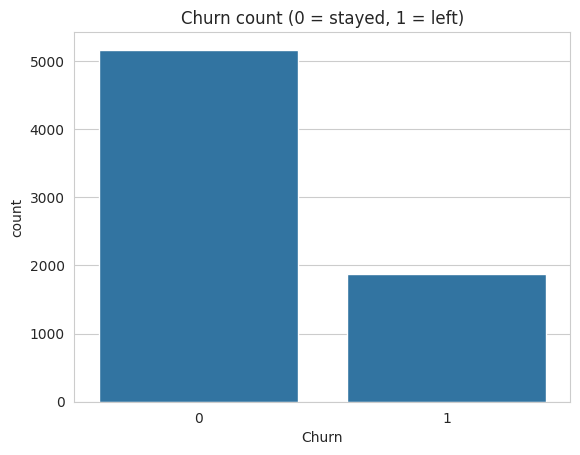


Churn rate by Contract (%):
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64

Churn rate by InternetService (%):
InternetService
Fiber optic    41.9
DSL            19.0
No              7.4
Name: Churn, dtype: float64

Churn rate by PaymentMethod (%):
PaymentMethod
Electronic check             45.3
Mailed check                 19.2
Bank transfer (automatic)    16.7
Credit card (automatic)      15.3
Name: Churn, dtype: float64

Churn rate by TechSupport (%):
TechSupport
No                     41.6
Yes                    15.2
No internet service     7.4
Name: Churn, dtype: float64

Churn rate by OnlineSecurity (%):
OnlineSecurity
No                     41.8
Yes                    14.6
No internet service     7.4
Name: Churn, dtype: float64

Churn rate by gender (%):
gender
Female    27.0
Male      26.2
Name: Churn, dtype: float64

Churn rate by SeniorCitizen (%):
SeniorCitizen
1    41.7
0    23.7
Name: Churn, dtype: float64


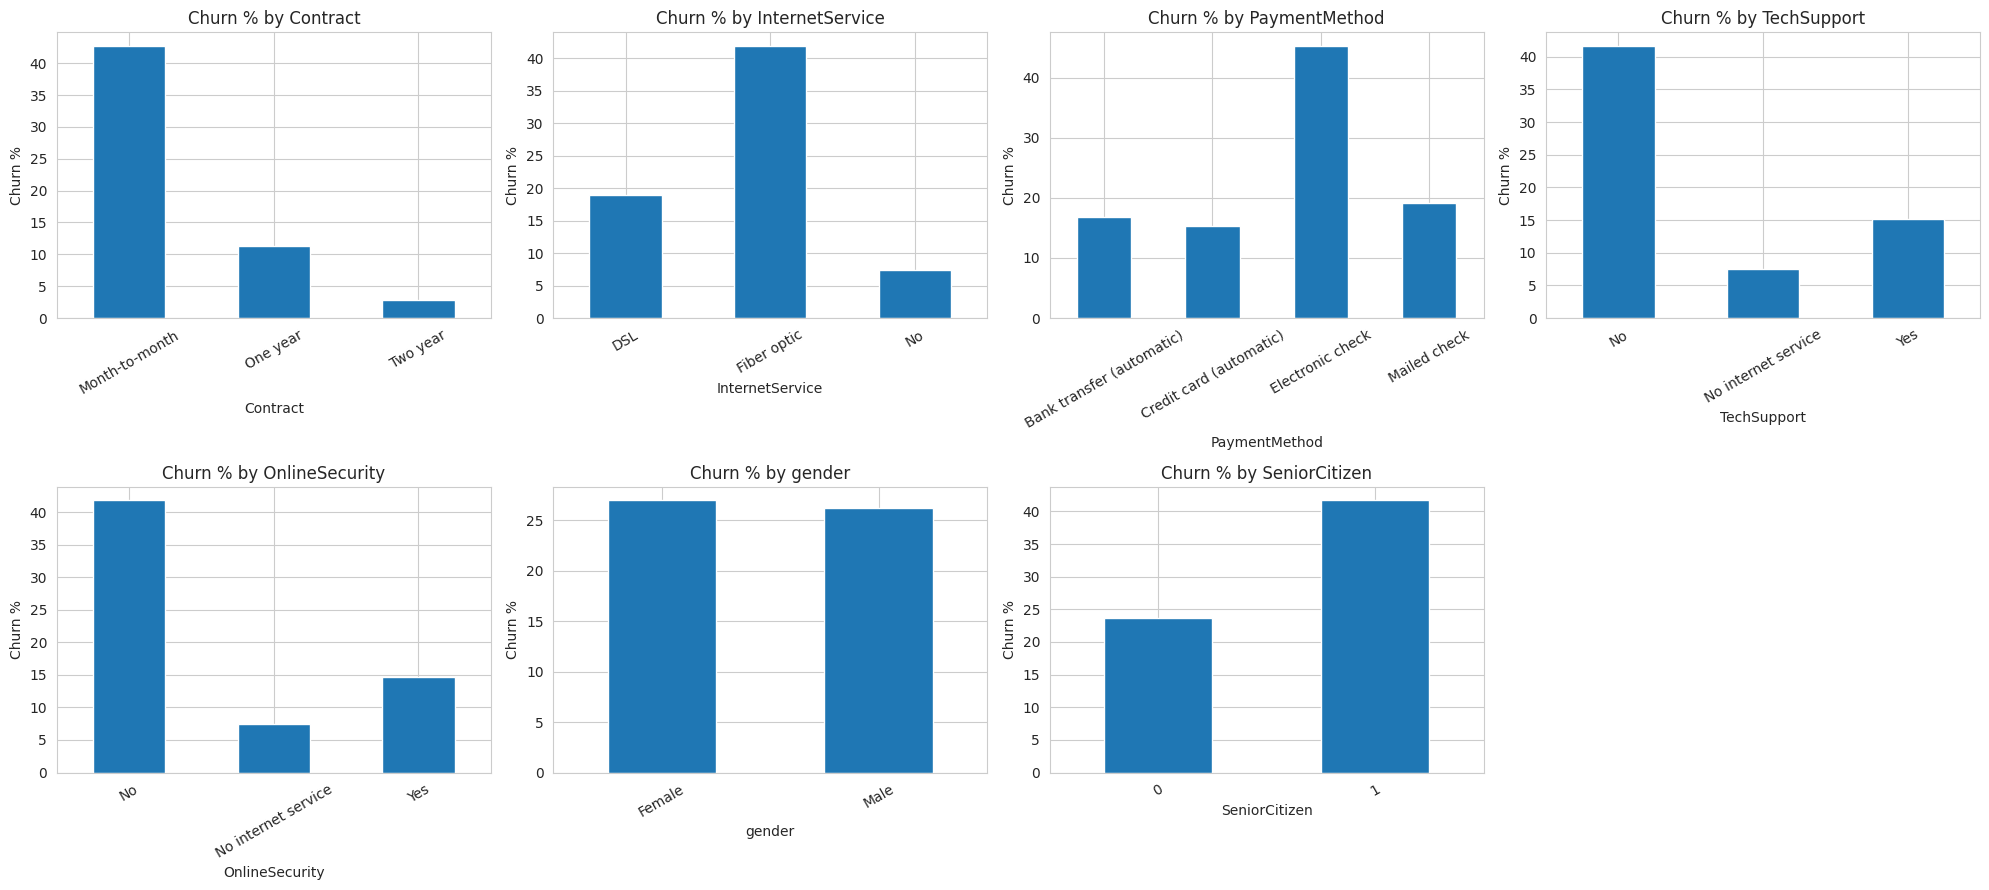

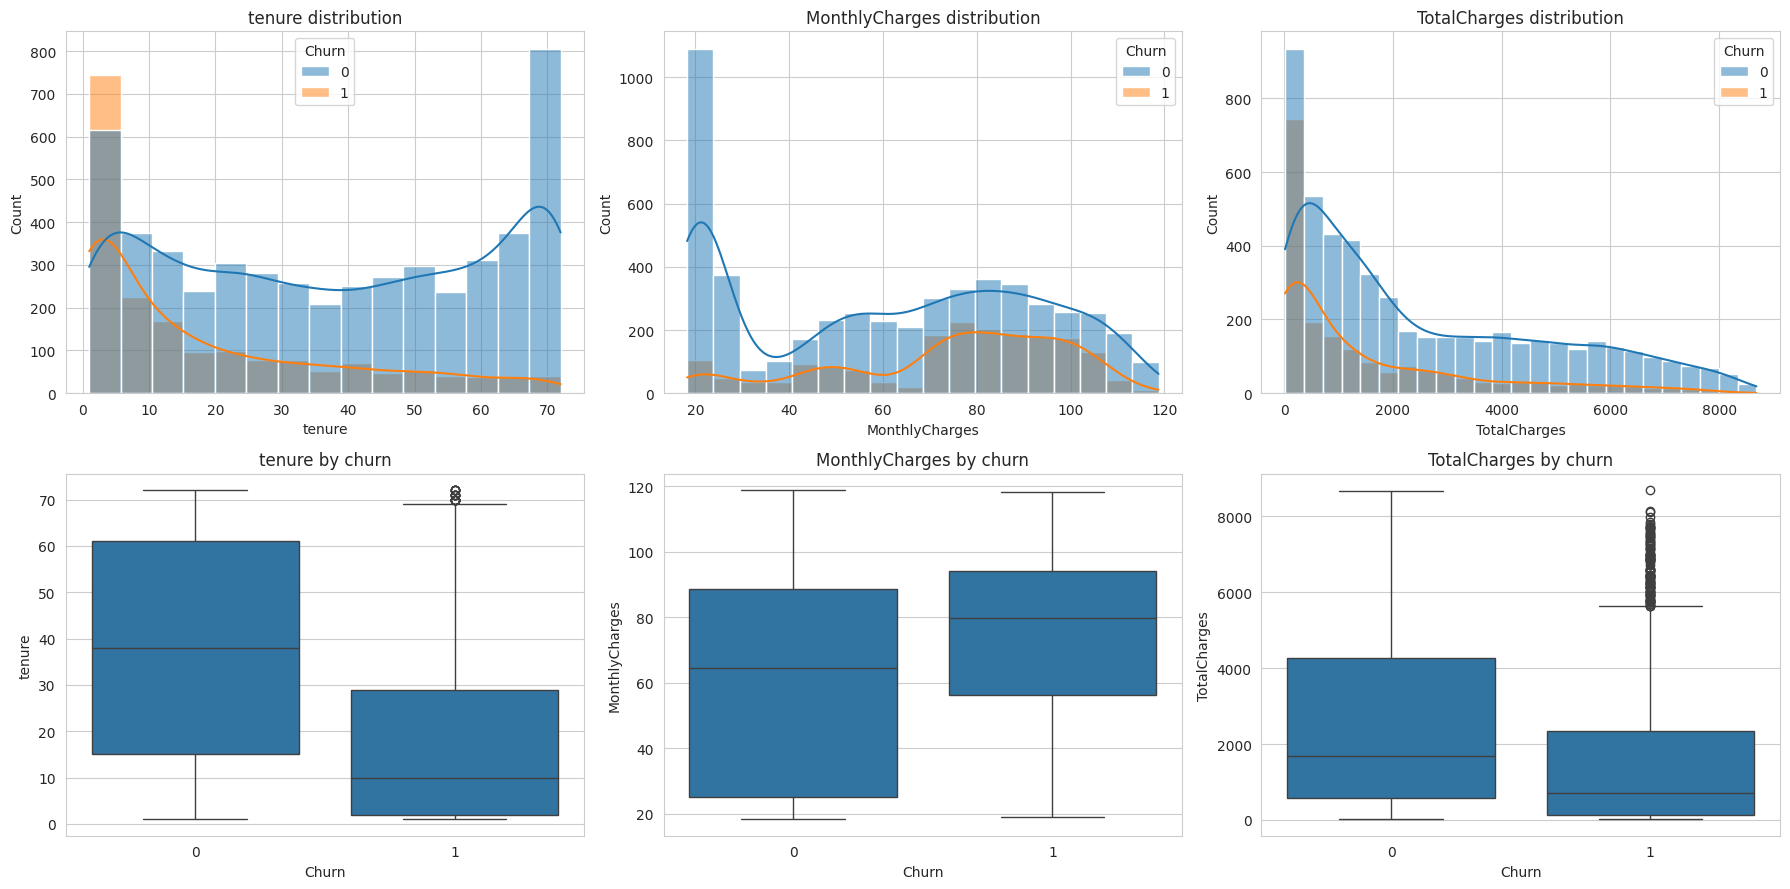

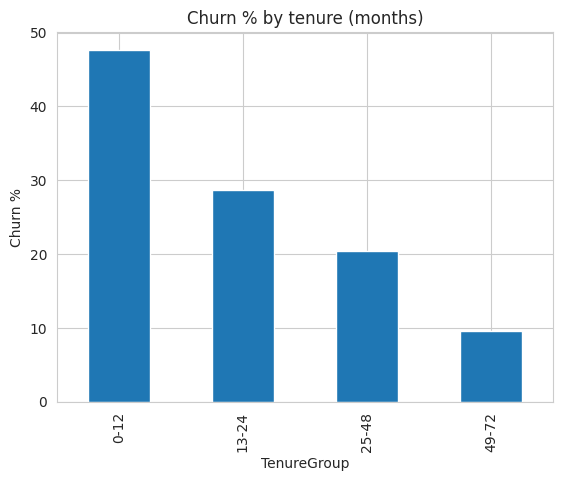

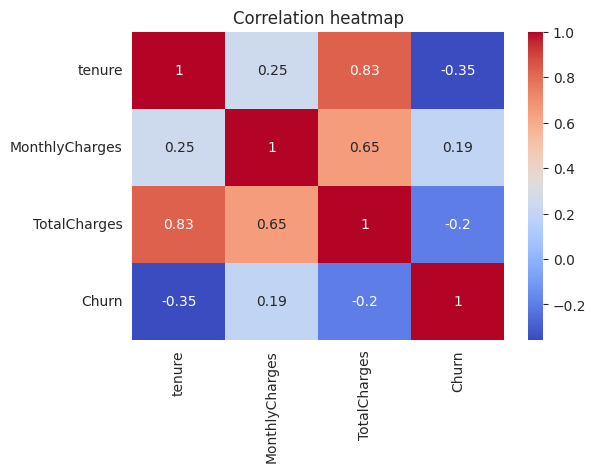

In [ ]:
# Step 2: EDA for Telco Customer Churn
# Run in Jupyter/Colab. Each "# %%" block = one notebook cell.

# %% Imports + Step 1 (load and clean)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna().drop("customerID", axis=1)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# %% 1. Overall churn rate
print(df["Churn"].value_counts(normalize=True) * 100)
sns.countplot(x="Churn", data=df)
plt.title("Churn count (0 = stayed, 1 = left)")
plt.show()

# %% 2. Churn rate by categorical columns
cat_cols = ["Contract", "InternetService", "PaymentMethod",
            "TechSupport", "OnlineSecurity", "gender", "SeniorCitizen"]

for col in cat_cols:
    rate = df.groupby(col)["Churn"].mean().sort_values(ascending=False) * 100
    print(f"\nChurn rate by {col} (%):\n{rate.round(1)}")

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, col in zip(axes.flatten(), cat_cols):
    df.groupby(col)["Churn"].mean().mul(100).plot(kind="bar", ax=ax)
    ax.set_title(f"Churn % by {col}")
    ax.set_ylabel("Churn %")
    ax.tick_params(axis="x", rotation=30)
axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.show()

# %% 3. Numeric columns vs churn
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue="Churn", kde=True, ax=axes[0, i])
    sns.boxplot(data=df, x="Churn", y=col, ax=axes[1, i])
    axes[0, i].set_title(f"{col} distribution")
    axes[1, i].set_title(f"{col} by churn")
plt.tight_layout()
plt.show()

# %% 4. Tenure groups (easy business insight)
df["TenureGroup"] = pd.cut(df["tenure"], bins=[0, 12, 24, 48, 72],
                           labels=["0-12", "13-24", "25-48", "49-72"])
df.groupby("TenureGroup", observed=True)["Churn"].mean().mul(100).plot(kind="bar")
plt.title("Churn % by tenure (months)")
plt.ylabel("Churn %")
plt.show()

# %% 5. Correlation heatmap (numeric + churn)
plt.figure(figsize=(6, 4))
sns.heatmap(df[num_cols + ["Churn"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation heatmap")
plt.show()

In [ ]:
# Step 3: Preprocessing for Telco Customer Churn
# Run in Jupyter/Colab. Each "# %%" block = one notebook cell.
# (If imblearn is missing in Colab, run:  !pip install imbalanced-learn )

# %% Imports + load and clean (same as Step 1)
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna().drop("customerID", axis=1)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# %% 1. Clean categories: "No internet service" / "No phone service" -> "No"
df = df.replace({"No internet service": "No", "No phone service": "No"})

# %% 2. Split into features (X) and target (y)
X = df.drop("Churn", axis=1)
y = df["Churn"]

# %% 3. One-hot encode all categorical columns
X = pd.get_dummies(X, drop_first=True, dtype=int)
print("Features after encoding:", X.shape)

# %% 4. Train/test split (80/20, stratified keeps the churn ratio equal)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train churn %:", round(y_train.mean() * 100, 1))
print("Test churn %:", round(y_test.mean() * 100, 1))

# %% 5. Scale numeric columns (fit on train ONLY, then apply to test)
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()

X_train_sc = X_train.copy()
X_test_sc = X_test.copy()
X_train_sc[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_sc[num_cols] = scaler.transform(X_test[num_cols])

# %% 6. Handle imbalance with SMOTE (TRAIN data only, never the test data)
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

print("\nBefore SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_sm.value_counts())

# Ready for Step 4:
#   X_train_sm, y_train_sm  -> train the models
#   X_test_sc,  y_test      -> evaluate the models

Features after encoding: (7032, 23)
Train churn %: 26.6
Test churn %: 26.6

Before SMOTE:
 Churn
0    4130
1    1495
Name: count, dtype: int64

After SMOTE:
 Churn
0    4130
1    4130
Name: count, dtype: int64


In [ ]:
# Step 4: Train and compare models for Telco Customer Churn
# Run in Jupyter/Colab. Each "# %%" block = one notebook cell.
# (If a library is missing in Colab, run:  !pip install imbalanced-learn xgboost )

# %% Imports + Step 3 preprocessing (self-contained, so it runs on its own)
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna().drop("customerID", axis=1)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df = df.replace({"No internet service": "No", "No phone service": "No"})

X = pd.get_dummies(df.drop("Churn", axis=1), drop_first=True, dtype=int)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()
X_train_sc, X_test_sc = X_train.copy(), X_test.copy()
X_train_sc[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_sc[num_cols] = scaler.transform(X_test[num_cols])

X_train_sm, y_train_sm = SMOTE(random_state=42).fit_resample(X_train_sc, y_train)

# %% 1. Define the three models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=4,
                             eval_metric="logloss", random_state=42),
}

# %% 2. Train each model on the SMOTE-balanced train data, test on the real test data
results = []
trained = {}

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    trained[name] = model

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
    })

# %% 3. Comparison table
results_df = pd.DataFrame(results).set_index("Model").round(3)
print(results_df)

# Ready for Step 5: confusion matrix, ROC curve, feature importance
#   trained["XGBoost"], trained["Random Forest"], trained["Logistic Regression"]

                     Accuracy  Precision  Recall     F1  ROC-AUC
Model                                                           
Logistic Regression     0.746      0.515   0.743  0.608    0.828
Random Forest           0.769      0.556   0.647  0.598    0.817
XGBoost                 0.756      0.530   0.714  0.608    0.823


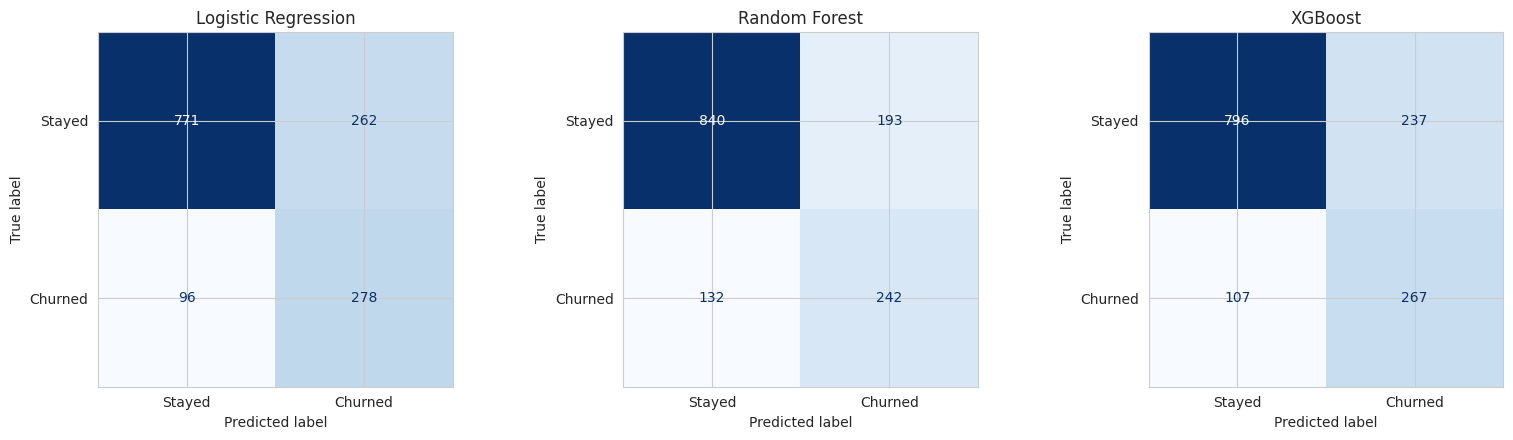

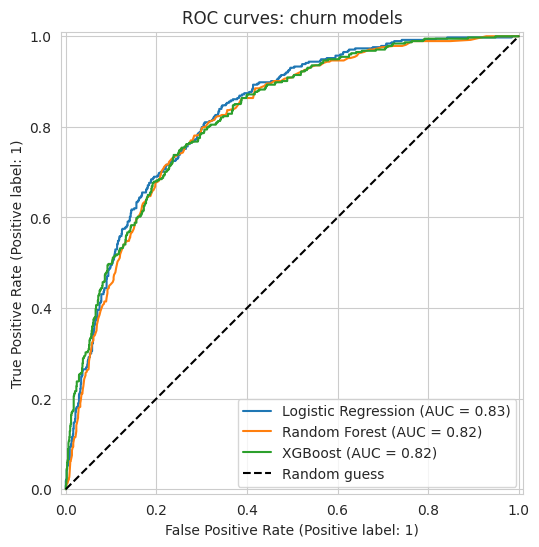

              precision    recall  f1-score   support

      Stayed       0.89      0.75      0.81      1033
     Churned       0.51      0.74      0.61       374

    accuracy                           0.75      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.75      0.76      1407



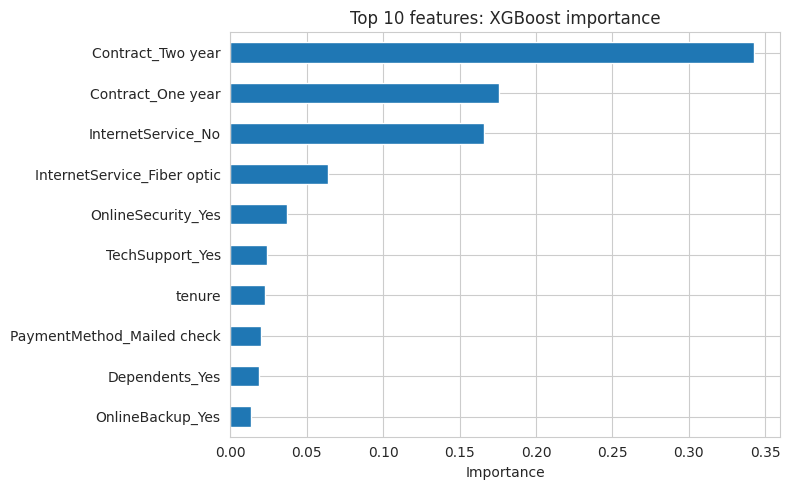

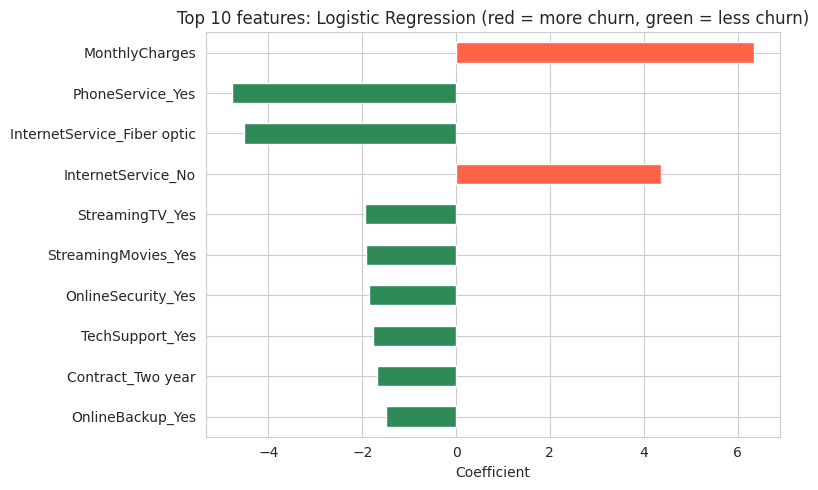

In [ ]:
# Step 5: Evaluation charts for Telco Customer Churn
# Run in Jupyter/Colab. Each "# %%" block = one notebook cell.
# (If a library is missing in Colab, run:  !pip install imbalanced-learn xgboost )

# %% Imports + Steps 3-4 (self-contained: preprocessing and model training)
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay,
                             classification_report)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna().drop("customerID", axis=1)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df = df.replace({"No internet service": "No", "No phone service": "No"})

X = pd.get_dummies(df.drop("Churn", axis=1), drop_first=True, dtype=int)
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()
X_train_sc, X_test_sc = X_train.copy(), X_test.copy()
X_train_sc[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_sc[num_cols] = scaler.transform(X_test[num_cols])
X_train_sm, y_train_sm = SMOTE(random_state=42).fit_resample(X_train_sc, y_train)

trained = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=4,
                             eval_metric="logloss", random_state=42),
}
for model in trained.values():
    model.fit(X_train_sm, y_train_sm)

# %% 1. Confusion matrices (rows = actual, columns = predicted)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, model) in zip(axes, trained.items()):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test_sc, y_test, display_labels=["Stayed", "Churned"],
        cmap="Blues", ax=ax, colorbar=False
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

# %% 2. ROC curves, all three models on one plot
fig, ax = plt.subplots(figsize=(7, 6))
for name, model in trained.items():
    RocCurveDisplay.from_estimator(model, X_test_sc, y_test, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Random guess")
ax.set_title("ROC curves: churn models")
ax.legend(loc="lower right")
plt.show()

# %% 3. Detailed report for the model you pick (change the name if needed)
best = "Logistic Regression"
print(classification_report(y_test, trained[best].predict(X_test_sc),
                            target_names=["Stayed", "Churned"]))

# %% 4. Feature importance: XGBoost (what matters most)
xgb_imp = pd.Series(trained["XGBoost"].feature_importances_, index=X.columns)
xgb_imp.sort_values().tail(10).plot(kind="barh", figsize=(8, 5))
plt.title("Top 10 features: XGBoost importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# %% 5. Logistic Regression coefficients (shows the DIRECTION of each effect)
coef = pd.Series(trained["Logistic Regression"].coef_[0], index=X.columns)
top = coef.reindex(coef.abs().sort_values().tail(10).index)
top.plot(kind="barh", figsize=(8, 5),
         color=["tomato" if v > 0 else "seagreen" for v in top])
plt.title("Top 10 features: Logistic Regression (red = more churn, green = less churn)")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()